In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import numpy as np
from scipy import stats
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import kruskal
import scipy.stats as stats
import scikit_posthocs as sp
import statsmodels.formula.api as smf
import statsmodels.formula.api as smf

In [2]:
# Cargo los datos
clientes = pd.read_csv("telecom_clients.csv")
dataset = pd.read_csv("telecom_dataset_new.csv")
clientes.info()
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 

### Pre-procesamiento

In [ ]:
# Convertir datos de fecha a datetime
clientes["date_start"] = pd.to_datetime(clientes['date_start'])
dataset["date"] = pd.to_datetime(dataset['date'])
# Calculo tiempo de espera
dataset["t_espera"] = dataset["total_call_duration"] - dataset["call_duration"]
# Transformo tipo de dato aquellas columnas con varibles binarias (0,1) que están como object y booleano
dataset["internal"] = dataset["internal"].astype("Int64")
dataset["direction"] = dataset["direction"].replace({"in": 0, "out": 1})
dataset["is_missed_call"] = dataset["is_missed_call"].astype(int)
# Simplifico la fecha quitándo el componente de las horas, porque siempre es la misma hora y no aporta información de valor
dataset["date"] = dataset["date"].dt.date
dataset["date"] = pd.to_datetime(dataset['date'])
# Creo columna con nombre del dia, para una futura curva de llamadas
dataset["weekday"] = dataset["date"].dt.day_name()

dataset.info()
clientes.info()
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              53902 non-null  int64         
 1   date                 53902 non-null  datetime64[ns]
 2   direction            53902 non-null  int64         
 3   internal             53785 non-null  Int64         
 4   operator_id          45730 non-null  float64       
 5   is_missed_call       53902 non-null  int64         
 6   calls_count          53902 non-null  int64         
 7   call_duration        53902 non-null  int64         
 8   total_call_duration  53902 non-null  int64         
 9   t_espera             53902 non-null  int64         
 10  weekday              53902 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(7), object(1)
memory usage: 4.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entri

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18444\2303892961.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset["direction"] = dataset["direction"].replace({"in": 0, "out": 1})


In [4]:
# Investigo si hay duplicados en los dataframes
# Duplicados en clientes
clientes_duplicadas = clientes[clientes.duplicated()]
print(clientes_duplicadas)
# Cuplicados en dataset o en el registro de llamadas
data_duplicadas = dataset[dataset.duplicated(keep=False)] \
                        .sort_values(by=["user_id", "date"])
data_duplicadas = data_duplicadas.reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print(data_duplicadas.iloc[0:10])
print(data_duplicadas.shape)


Empty DataFrame
Columns: [user_id, tariff_plan, date_start]
Index: []
   user_id       date  direction  internal  operator_id  is_missed_call  \
0   166377 2019-08-05          1         0     880020.0               1   
1   166377 2019-08-05          1         0     880020.0               1   
2   166377 2019-08-12          0         0          NaN               1   
3   166377 2019-08-12          0         0          NaN               1   
4   166377 2019-08-14          0         0          NaN               1   
5   166377 2019-08-14          1         0     880026.0               0   
6   166377 2019-08-14          1         0     880026.0               0   
7   166377 2019-08-14          0         0          NaN               1   
8   166377 2019-08-15          1         0     880026.0               0   
9   166377 2019-08-15          1         0     880026.0               0   

   calls_count  call_duration  total_call_duration  t_espera    weekday  
0            8              0 

El dataset de clientes no contiene filas duplicadas, sin embargo el dataset de registros telefónicos tiene 4900 filas repetidas, el 9% de los datos. Estas deben ser elimminadas para evitar sesgos en los análisis.

In [5]:
# Elimino duplicados de tabla de registros telefónicos
dataset_no_duplicados = dataset.drop_duplicates(keep="first")
print(dataset_no_duplicados.shape)

(49002, 11)


In [6]:
# Uno los datasets (clientes y registros telefónicos) para análisis futuros. No incluyo la fecha de registro en la unión...
dataset_merge = dataset_no_duplicados.merge(
    clientes[["user_id", "tariff_plan"]],
    on="user_id",
    how="left"
)

dataset_merge.info()
print(dataset_merge.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              49002 non-null  int64         
 1   date                 49002 non-null  datetime64[ns]
 2   direction            49002 non-null  int64         
 3   internal             48892 non-null  Int64         
 4   operator_id          41546 non-null  float64       
 5   is_missed_call       49002 non-null  int64         
 6   calls_count          49002 non-null  int64         
 7   call_duration        49002 non-null  int64         
 8   total_call_duration  49002 non-null  int64         
 9   t_espera             49002 non-null  int64         
 10  weekday              49002 non-null  object        
 11  tariff_plan          49002 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(7), object(2)
memory usage: 4.5+ MB
  

#### Exploración

In [7]:
# Cuántos operadores tiene la empresa?
print(dataset_merge["operator_id"].nunique())
# Cuantos usuarios únicos tiene la empresa?
print(dataset_merge["user_id"].nunique())

1092
307


El callcenter cuenta con 307 usuarios y 1092 operarios.

In [8]:
# Proporcion de la direccion de las llamadas
print(dataset_merge["direction"].value_counts(normalize=True))
# Proporción de las llamadas internas
print(dataset_merge["internal"].value_counts(normalize=True))
# Proporción llamadas perdidas
print(dataset_merge["is_missed_call"].value_counts(normalize=True))
# Usuarios por grupo tarifario
users_tariff = dataset_merge.groupby("tariff_plan")["user_id"].nunique()
print(users_tariff)

direction
1    0.591792
0    0.408208
Name: proportion, dtype: float64
internal
0    0.884378
1    0.115622
Name: proportion, dtype: Float64
is_missed_call
0    0.562202
1    0.437798
Name: proportion, dtype: float64
tariff_plan
A     34
B    112
C    161
Name: user_id, dtype: int64


El 59% de las llamadas son iniciadas desde el Call Center, lo que sugiere una estrategia de contacto principalmente proactiva por parte de la empresa. Se evidencia un porcentaje elevado de llamadas perdidas (43%), lo cual representa una oportunidad crítica de mejora en la gestión operativa. En cuanto a la segmentación por planes tarifarios, el plan C concentra la mayor proporción de usuarios (161), seguido por el plan B (112), mientras que el plan A representa una participación significativamente menor (34 usuarios).

In [9]:
# Cuantas llamadas promedio responde un operario?
entrantes_respondidas = dataset_merge[
    (dataset_merge["direction"] == 0) &
    (dataset_merge["is_missed_call"] == 0)
]
llamadas_por_operador = entrantes_respondidas.groupby("operator_id").size()
print(f"El número promedio de llamadas NO perdidas o atendidas por operador es: {llamadas_por_operador.mean():.0f}")

# Cunántas llamadas promedio pierde un operario (llamadas perdidas)?
entrantes_perdidas = dataset_merge[
    (dataset_merge["direction"] == 0) &
    (dataset_merge["is_missed_call"] == 1)
]
llamadas_por_operador = entrantes_perdidas.groupby("operator_id").size()
print(f"El número promedio de llamadas NO atendidas o llamadas perdidas por operador es: {llamadas_por_operador.mean():.0f}")

# Cuántas llamadas promedio realiza un operario y son atendidas? 
salientes_respondidas = dataset_merge[
    (dataset_merge["direction"] == 1) &
    (dataset_merge["is_missed_call"] == 0)
]

llamadas_por_operador = salientes_respondidas.groupby("operator_id").size()
print(f"El número promedio de llamadas realizadas por operario y atendidas por el usuario es: {llamadas_por_operador.mean():.0f}")

# Cuántas llamadas promedio realiza un operario y son perdidas? 
salientes_perdidas = dataset_merge[
    (dataset_merge["direction"] == 1) &
    (dataset_merge["is_missed_call"] == 1)
]

llamadas_por_operador = salientes_perdidas.groupby("operator_id").size()

print(f"El número promedio de llamadas realizadas y perdidas por operador es: {llamadas_por_operador.mean():.0f}")
 
### AHORA EN PORCENTAJE
# Total de llamadas entrantes por operador
entrantes_totales = dataset_merge[
    dataset_merge["direction"] == 0
].groupby("operator_id").size()

# Llamadas salientes perdidas por operador
entrantes_perdidas = dataset_merge[
    (dataset_merge["direction"] == 0) &
    (dataset_merge["is_missed_call"] == 1)
].groupby("operator_id").size()

# Calcular proporción
tasa_perdidas = (entrantes_perdidas / entrantes_totales)

# Promedio de la tasa entre operadores
print(f"La tasa promedio de llamadas entrantes perdidas por operador es: {tasa_perdidas.mean():.2%}")
print(f"La tasa promedio de llamadas entrantes atendidas por operador es: {1-tasa_perdidas.mean():.2%}")


# Total de llamadas salientes por operador
salientes_totales = dataset_merge[
    dataset_merge["direction"] == 1
].groupby("operator_id").size()

# Llamadas salientes perdidas por operador
salientes_perdidas = dataset_merge[
    (dataset_merge["direction"] == 1) &
    (dataset_merge["is_missed_call"] == 1)
].groupby("operator_id").size()

# Calcular proporción
tasa_perdidas = (salientes_perdidas / salientes_totales)

# Promedio de la tasa entre operadores
print(f"La tasa promedio de llamadas salientes perdidas por operador es: {tasa_perdidas.mean():.2%}")
print(f"La tasa promedio de llamadas salientes y recibidas por operador es: {1- tasa_perdidas.mean():.2%}")

# Cual es el TOM proedio de la empresa?
TOM = dataset_merge[
    (dataset_merge["is_missed_call"] == 0)]

print(f"El tiempo promedio de conversión en la llamada es: {TOM['call_duration'].mean()/60:.0f} minutos")
# Cuál es el tiempo de espera promedio de la empresa?
espera = dataset_merge[
    dataset_merge["is_missed_call"] == 0
]

print(f"El tiempo de espera promedio en la llamada es: {espera['t_espera'].mean()/60:.0f} minutos")

El número promedio de llamadas NO perdidas o atendidas por operador es: 16
El número promedio de llamadas NO atendidas o llamadas perdidas por operador es: 3
El número promedio de llamadas realizadas por operario y atendidas por el usuario es: 19
El número promedio de llamadas realizadas y perdidas por operador es: 16
La tasa promedio de llamadas entrantes perdidas por operador es: 11.70%
La tasa promedio de llamadas entrantes atendidas por operador es: 88.30%
La tasa promedio de llamadas salientes perdidas por operador es: 51.47%
La tasa promedio de llamadas salientes y recibidas por operador es: 48.53%
El tiempo promedio de conversión en la llamada es: 26 minutos
El tiempo de espera promedio en la llamada es: 4 minutos


La operación parece estar estructuralmente orientada a la proactividad (alto volumen de llamadas salientes), pero con una baja tasa de contacto efectivo, lo que sugiere que el principal desafío no está en la capacidad de atención, sino en la eficiencia de la estrategia de contacto.

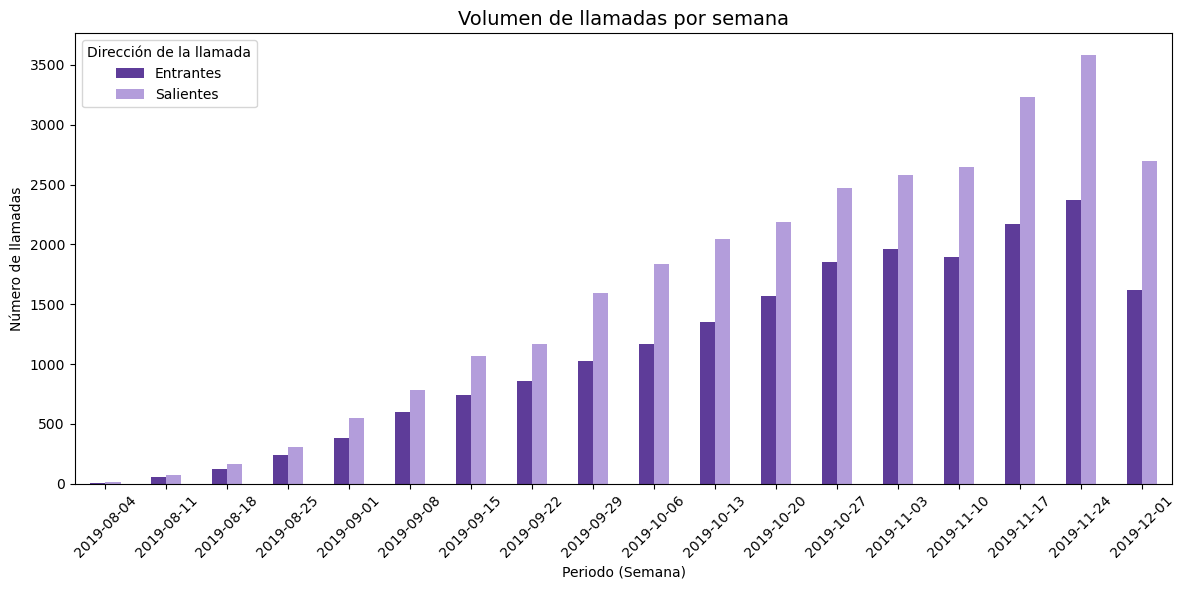

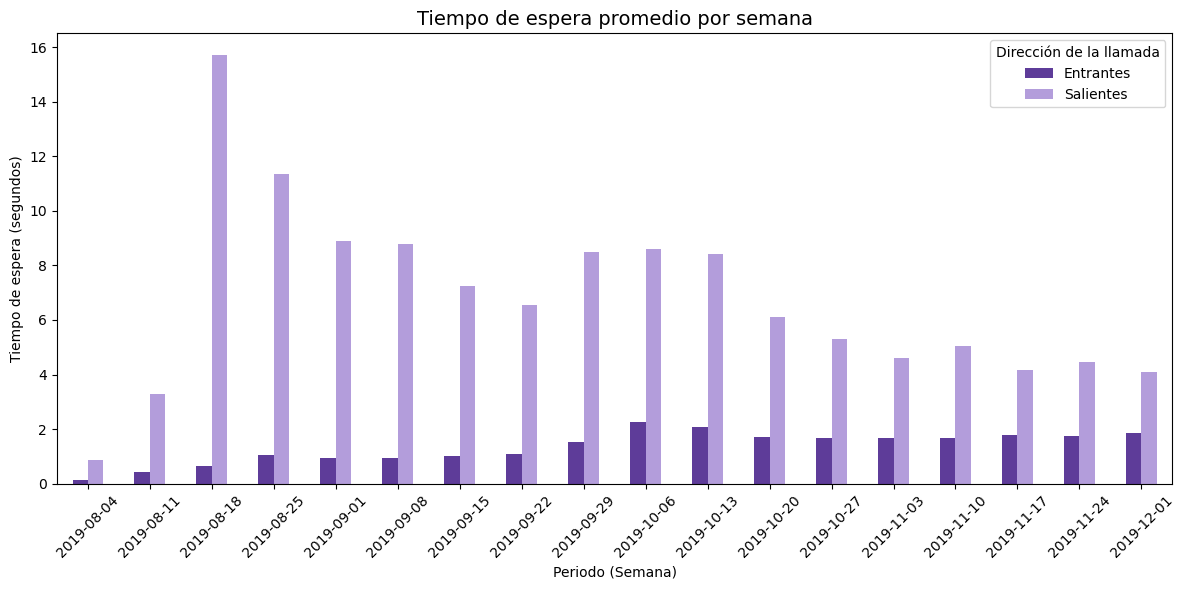

In [18]:
# Serie de tiempo del número de llamadas en el callcenter
calls_week = (
    dataset_merge
    .groupby([
        pd.Grouper(key="date", freq="W"), 
        "direction"
    ])
    .size()
    .unstack(fill_value=0)
)
calls_week = calls_week.rename(columns={
    0: "Entrantes",
    1: "Salientes"
})
calls_week.index = calls_week.index.strftime("%Y-%m-%d")

ax = calls_week.plot(
    kind="bar",
    figsize=(12,6),
    color=["#5E3C99", "#B39DDB"]
)

ax.set_title("Volumen de llamadas por semana", fontsize=14)
ax.set_xlabel("Periodo (Semana)")
ax.set_ylabel("Número de llamadas")
ax.legend(title="Dirección de la llamada")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ¿El tiempo de espera se hace cada vez más largo?
# Serie de tiempo de espera de llamadas en el callcenter
# Filtro para que las llamadas perdidas no hayan ruido
espera_week = (
    dataset_merge[dataset_merge["is_missed_call"] == 0]
    .groupby([
        pd.Grouper(key="date", freq="W"),
        "direction"
    ])["t_espera"]
    .mean()
    .unstack(fill_value=0)
)
espera_week.index = espera_week.index.strftime("%Y-%m-%d")
espera_week = espera_week.rename(columns={
    0: "Entrantes",
    1: "Salientes"
})
espera_week = espera_week / 60
ax = espera_week.plot(
    kind="bar",
    figsize=(12,6),
    color=["#5E3C99", "#B39DDB"]
)

ax.set_title("Tiempo de espera promedio por semana", fontsize=14)
ax.set_xlabel("Periodo (Semana)")
ax.set_ylabel("Tiempo de espera (segundos)")
ax.legend(title="Dirección de la llamada")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ¿?

A través de la visualización del volumen semanal de llamadas, se observa una tendencia creciente en el número total de interacciones, lo que sugiere un aumento sostenido en la actividad operativa y crecimiento empresarial del Call Center.

La segunda gráfica sugiere que, con el paso de las semanas, el tiempo de espera de las llamadas salientes ha venido disminuyendo, sin embargo, el tiempo de espera de las llamadas entrantes ha aumentado ligeramente. La reducción en el tiempo de espera de llamadas salientes sugiere una mejora en la eficiencia de los procesos proactivos del Call Center. Sin embargo, el aumento leve en el tiempo de espera de llamadas entrantes podría indicar una reasignación de recursos hacia la gestión saliente o un crecimiento en la demanda entrante que no ha sido completamente entendido por la capacidad operativa.

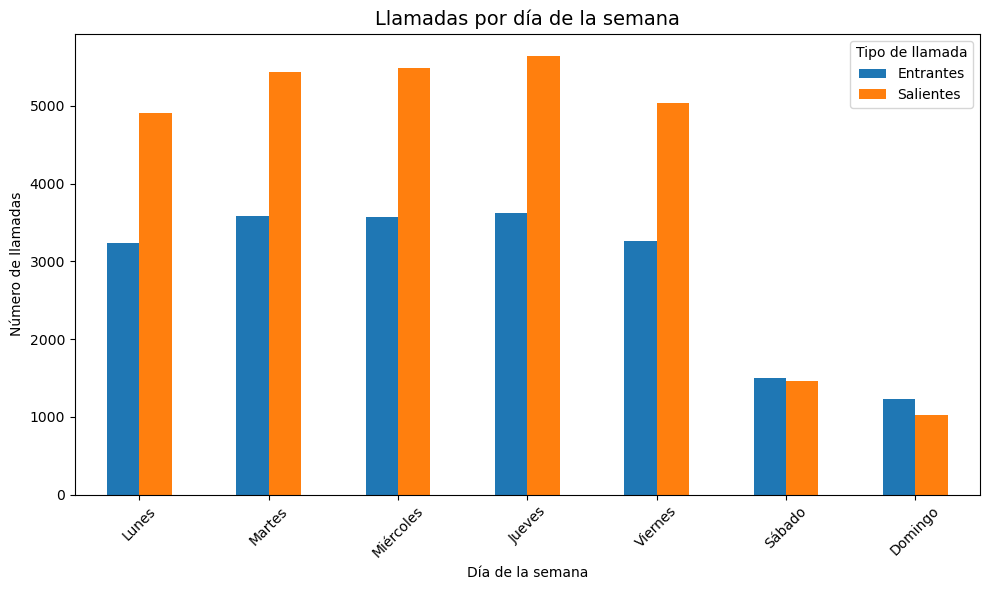

In [11]:
# Curva de llamadas por dia de la semana
dataset_merge["weekday_es"] = (
    dataset_merge["date"]
    .dt.day_name()
    .map({
        "Monday": "Lunes",
        "Tuesday": "Martes",
        "Wednesday": "Miércoles",
        "Thursday": "Jueves",
        "Friday": "Viernes",
        "Saturday": "Sábado",
        "Sunday": "Domingo"
    })
)
order = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

dataset_merge["weekday"] = pd.Categorical(
    dataset_merge["weekday"],
    categories=order,
    ordered=True
)

calls_weekday = (
    dataset_merge
    .groupby(["weekday_es", "direction"])
    .size()
    .unstack(fill_value=0)
)
calls_weekday = calls_weekday.reindex(order)

calls_weekday = calls_weekday.rename(columns={
    0: "Entrantes",
    1: "Salientes"
})

ax = calls_weekday.plot(
    kind="bar",
    figsize=(10,6),
    color=["#1f77b4", "#ff7f0e"]
)

ax.set_title("Llamadas por día de la semana", fontsize=14)
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Número de llamadas")
ax.legend(title="Tipo de llamada")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El mayor tráfico de llamadas ocurre entre semana, siendo el jueves el día de mayor llamadas. Entre semana las llamadas salientes están cerca o superan las 5000 llamadas, mientras que las llamadas entrantes están por debajo de las 4000. Los sábados tanto entrantes como salientes se reducen a la mitad, menos de 2000 llamadas en el día.

In [12]:
# Calcularé el FCR por usuario
# Primero filtraré las llamadas que NO fueron perdidas
dataset_calls = dataset_merge[dataset_merge["is_missed_call"]==0]
# Segundo ordeno dataframe
dataset_calls = dataset_calls.sort_values(["user_id", "date"])
# Creo columna de llamada futura
dataset_calls["next_call"] = (
    dataset_calls
    .groupby("user_id")["date"]
    .shift(-1)
)
# Encuentro la diferencia de tiempo entre la primera llamada y la siguiente llamada
dataset_calls["hours_until_next_call"] = (
    (dataset_calls["next_call"] - dataset_calls["date"])
    .dt.total_seconds() / 3600
)
# Definimos FCR, tomando como tiempo máximo 24 hrs para un siguiente intento de llamada
dataset_calls["FCR"] = (((dataset_calls["hours_until_next_call"].isna()) |
        (dataset_calls["hours_until_next_call"] >= 24)
    )
)
print(dataset_calls.head(5))

# Cual es el FCR promedio de la empresa?
print(f"El porcentaje de llamadas resueltas en la primera llamada (FCR) general de la empresa es {dataset_calls['FCR'].mean()*100:.2f}%")

    user_id       date  direction  internal  operator_id  is_missed_call  \
3    166377 2019-08-05          1         1     880020.0               0   
5    166377 2019-08-05          1         0     880020.0               0   
12   166377 2019-08-06          1         0     880020.0               0   
14   166377 2019-08-07          1         0     880026.0               0   
15   166377 2019-08-07          1         0     880020.0               0   

    calls_count  call_duration  total_call_duration  t_espera weekday  \
3             1             10                   18         8     NaN   
5             2              3                   29        26     NaN   
12            5            800                  819        19     NaN   
14            1             21                   28         7     NaN   
15            2            232                  240         8     NaN   

   tariff_plan weekday_es  next_call  hours_until_next_call    FCR  
3            B      Lunes 2019-08-0

In [17]:
dataset_calls["FCR"].mean()

np.float64(0.3025518167628589)

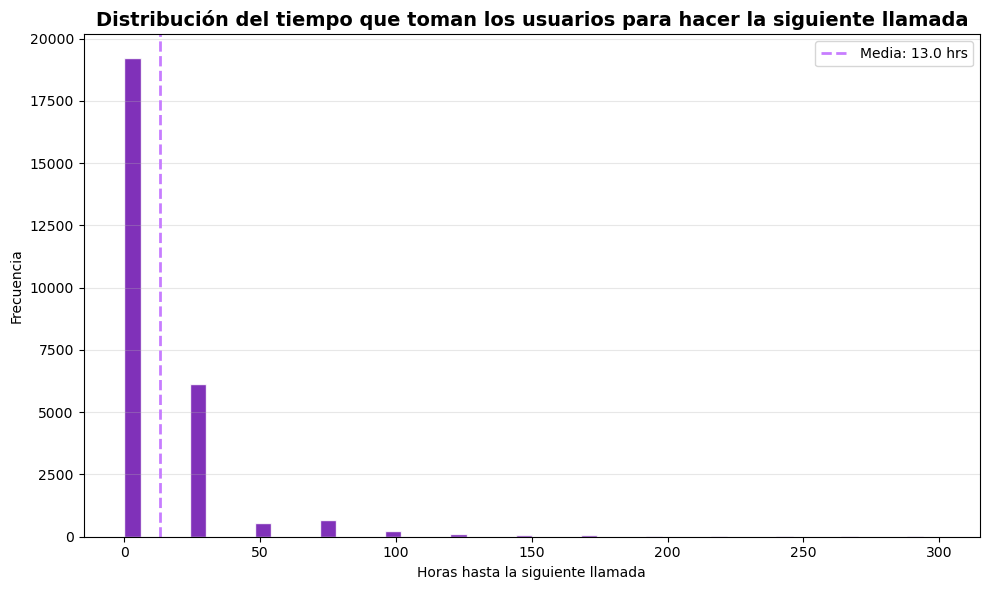

In [14]:
plt.figure(figsize=(10,6))

plt.hist(
    dataset_calls["hours_until_next_call"],
    bins=50,
    range=(0, 300),
    color="#6a0dad",          
    edgecolor="white",
    alpha=0.85
)

# Línea de la media
media = dataset_calls["hours_until_next_call"].mean()
plt.axvline(media, 
            color="#c77dff", 
            linestyle="--", 
            linewidth=2,
            label=f"Media: {media:.1f} hrs")

plt.title("Distribución del tiempo que toman los usuarios para hacer la siguiente llamada",
          fontsize=14,
          weight="bold")

plt.xlabel("Horas hasta la siguiente llamada")
plt.ylabel("Frecuencia")

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

En promedio, los usuarios ejecutan una nueva llamada a las 13 horas luego de su primera llamada contestada. El hecho de que los usuarios vuelvan a contactar en promedio en menos de 24 horas sugiere posibles oportunidades de mejora (o mecanismos de seguimiento) en la efectividad de resolución en el primer contacto.

operator_id
885876.0    135
891410.0    131
893804.0    130
901880.0    128
891414.0    126
           ... 
930510.0      0
930326.0      0
930264.0      0
929340.0      0
973286.0      0
Name: is_missed_call, Length: 1092, dtype: int64


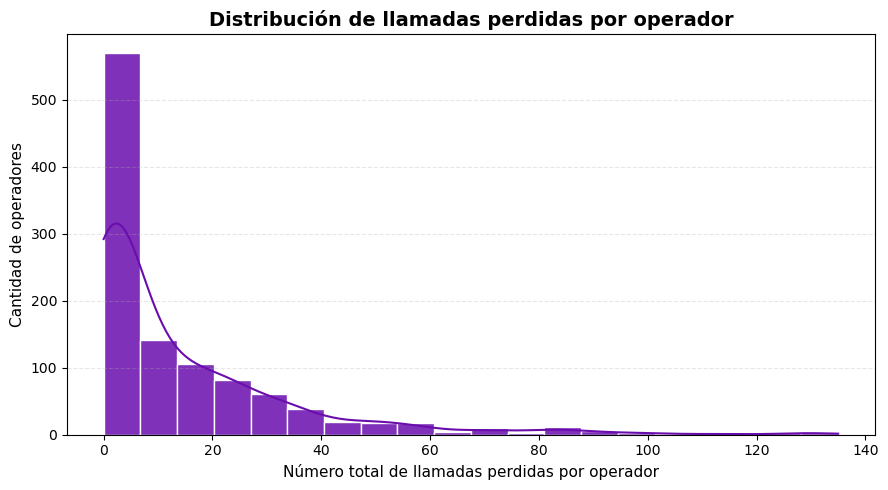

In [ ]:
# ¿En promedio cuantas llamadas perdidas tiene un operador?
missed_by_operator = dataset.groupby("operator_id")["is_missed_call"].sum()
print(missed_by_operator.sort_values(ascending=False))

plt.figure(figsize=(9,5))

sns.histplot(
    missed_by_operator,
    bins=20,
    kde=True,                     
    color="#6A0DAD",              
    edgecolor="white",
    alpha=0.85
)

plt.title(
    "Distribución de llamadas perdidas por operador",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Número total de llamadas perdidas por operador", fontsize=11)
plt.ylabel("Cantidad de operadores", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

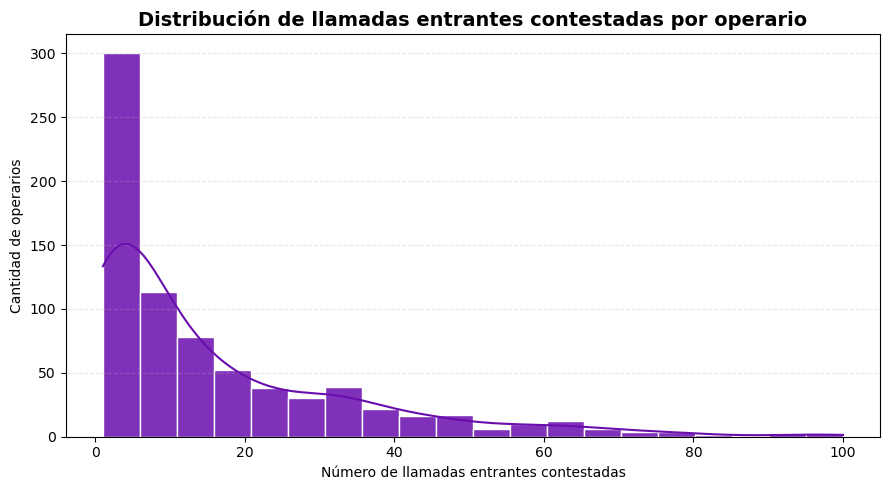

In [34]:
# CUantas llamadas entrantes contesta un operario?
answered_calls = dataset_merge[
    (dataset_merge["is_missed_call"] == 0) &
    (dataset_merge["direction"] == 0)
]
calls_per_user = (
    answered_calls
    .groupby("operator_id")
    .size()
    .reset_index(name="num_calls_answered")
)
# Grafico
plt.figure(figsize=(9,5))
sns.histplot(
    calls_per_user["num_calls_answered"],
    bins=20,
    kde=True,
    color="#6A0DAD",
    edgecolor="white",
    alpha=0.85
)
plt.title(
    "Distribución de llamadas entrantes contestadas por operario",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Número de llamadas entrantes contestadas")
plt.ylabel("Cantidad de operarios")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [75]:
# Prueba de normalidad de las variables objetivo
# Calls_count
data = dataset_merge["calls_count"].dropna()

stat, p_value = shapiro(data)

print("Estadístico:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("No se rechaza H0 → el número de intentos en cada llamada podrían seguir una distribución normal")
else:
    print("Se rechaza H0 → l número de intentos en cada llamada NO siguen una distribución normal")

# Call_duration
data = dataset_merge["call_duration"].dropna()

stat, p_value = shapiro(data)

print("Estadístico:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("No se rechaza H0 → la duración de la llamada podría seguir una distribución normal")
else:
    print("Se rechaza H0 → la duración de la llamada NO sigue una distribución normal")

Estadístico: 0.1900210980787066
p-value: 2.47811485853168e-156
Se rechaza H0 → l número de intentos en cada llamada NO siguen una distribución normal
Estadístico: 0.18888109921489948
p-value: 2.2335100277106714e-156
Se rechaza H0 → la duración de la llamada NO sigue una distribución normal


<Figure size 1000x600 with 0 Axes>

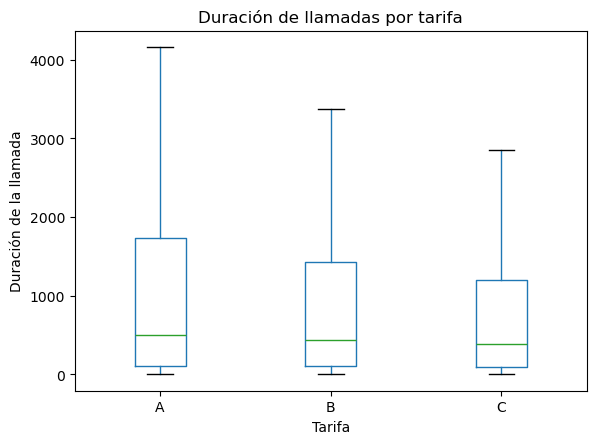

In [79]:
dataset_filtrado = dataset_merge[
    (dataset_merge["call_duration"] > 0) &
    (dataset_merge["call_duration"].notna())
]

plt.figure(figsize=(10,6))

dataset_filtrado.boxplot(
    column="call_duration",
    by="tariff_plan",
    grid=False, showfliers=False
)

plt.title("Duración de llamadas por tarifa")
plt.suptitle("")  # elimina el título automático
plt.xlabel("Tarifa")
plt.ylabel("Duración de la llamada")
plt.show()
plt.close()

In [78]:
# Prueba de homocedasticidad
groups = [
    group["calls_count"].dropna()
    for name, group in dataset_merge.groupby("tariff_plan")
]

# Aplicar prueba "call_count"
stat, p_value = levene(*groups)

print("Estadístico:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("No se rechaza H0 → el número de intentos en cada llamada por grupos tarifarios presenta Varianzas homogéneas")
else:
    print("Se rechaza H0 →  el número de intentos en cada llamada por grupos tarifarios presenta Varianzas NO homogéneas")

# Aplicar prueba "call_duration"
groups = [
    group["call_duration"].dropna()
    for name, group in dataset_merge.groupby("tariff_plan")
]
stat, p_value = levene(*groups)

print("Estadístico:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("No se rechaza H0 → la duración de la llamada por grupos tarifarios presenta Varianzas homogéneas")
else:
    print("Se rechaza H0 →  la duración de la llamada por grupos tarifarios presenta Varianzas NO homogéneas")

Estadístico: 591.53924765276
p-value: 1.4131198323544354e-254
Se rechaza H0 →  el número de intentos en cada llamada por grupos tarifarios presenta Varianzas NO homogéneas
Estadístico: 369.19400547902006
p-value: 7.197619596745978e-160
Se rechaza H0 →  la duración de la llamada por grupos tarifarios presenta Varianzas NO homogéneas


#### Exploración y Análisis por Grupos Trifarios

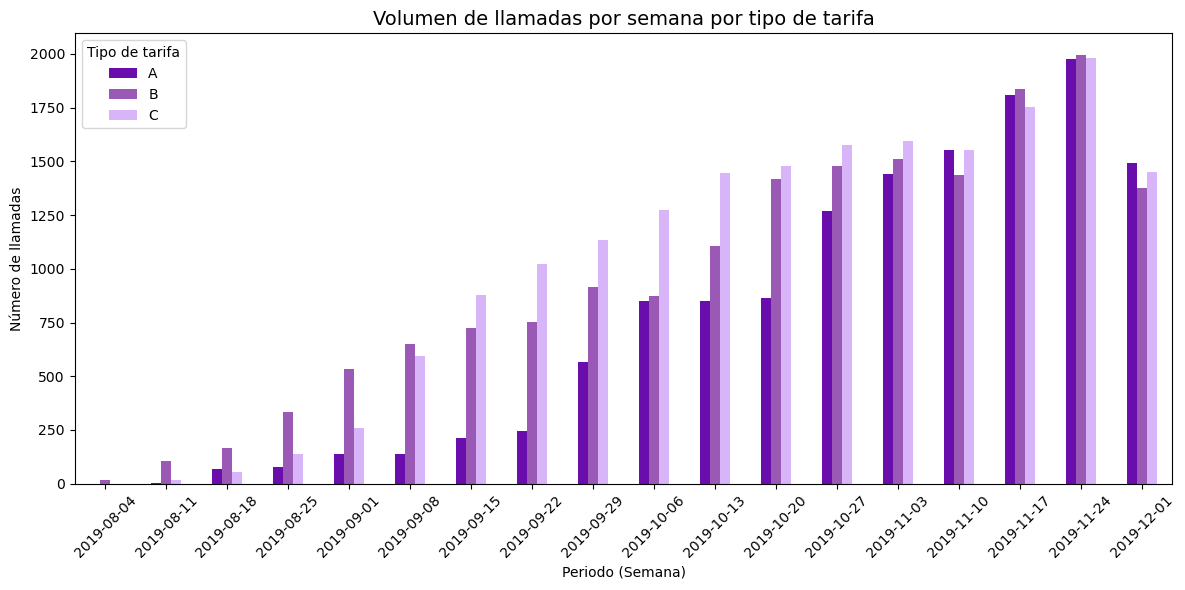

In [15]:
# Series de tiempo por tarifas
calls_group = (
    dataset_merge
    .groupby([
        pd.Grouper(key="date", freq="W"), 
        "tariff_plan"
    ])
    .size()
    .unstack(fill_value=0)
)

calls_group.index = calls_group.index.strftime("%Y-%m-%d")

ax = calls_group.plot(
    kind="bar",
    figsize=(12,6),
    color=["#6A0DAD", "#9B59B6", "#D8B4F8"]
)

ax.set_title("Volumen de llamadas por semana por tipo de tarifa", fontsize=14)
ax.set_xlabel("Periodo (Semana)")
ax.set_ylabel("Número de llamadas")
ax.legend(title="Tipo de tarifa")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

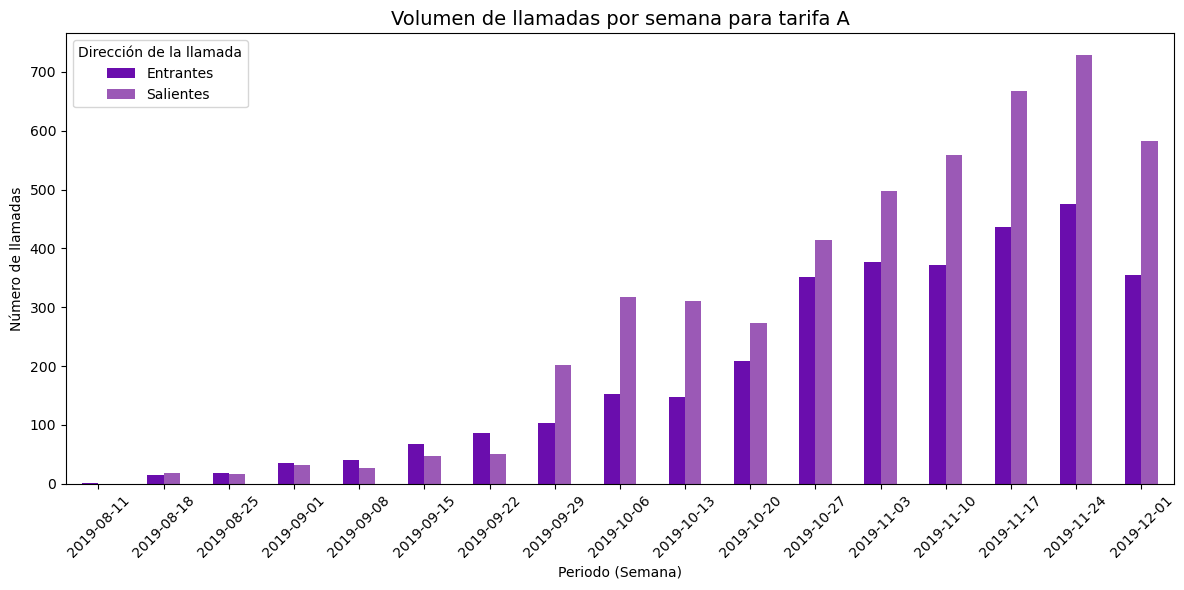

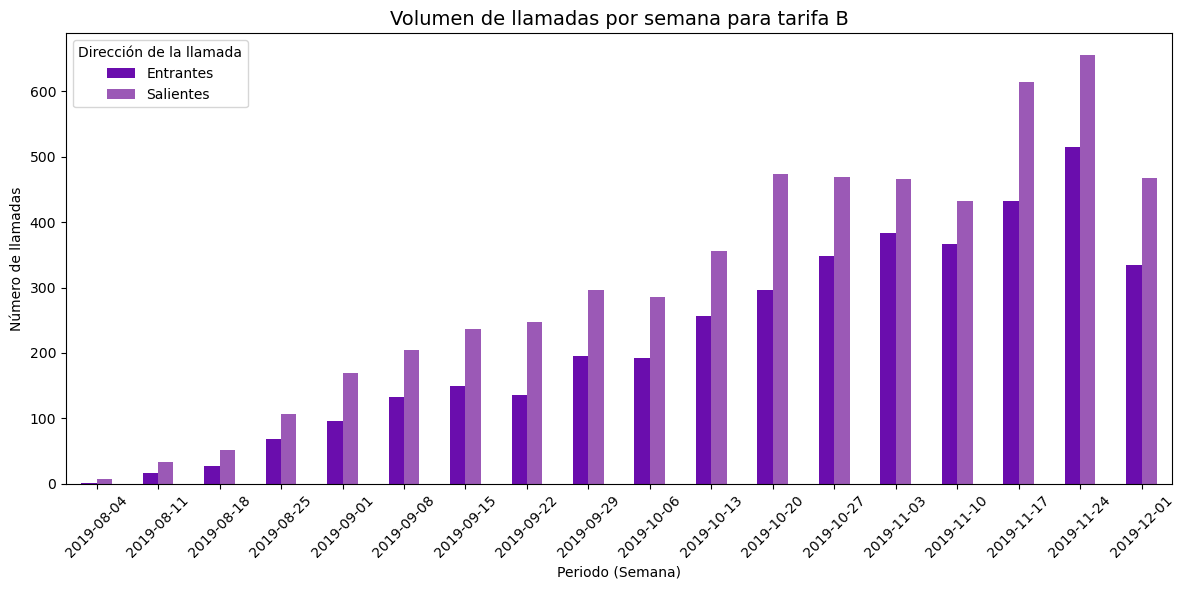

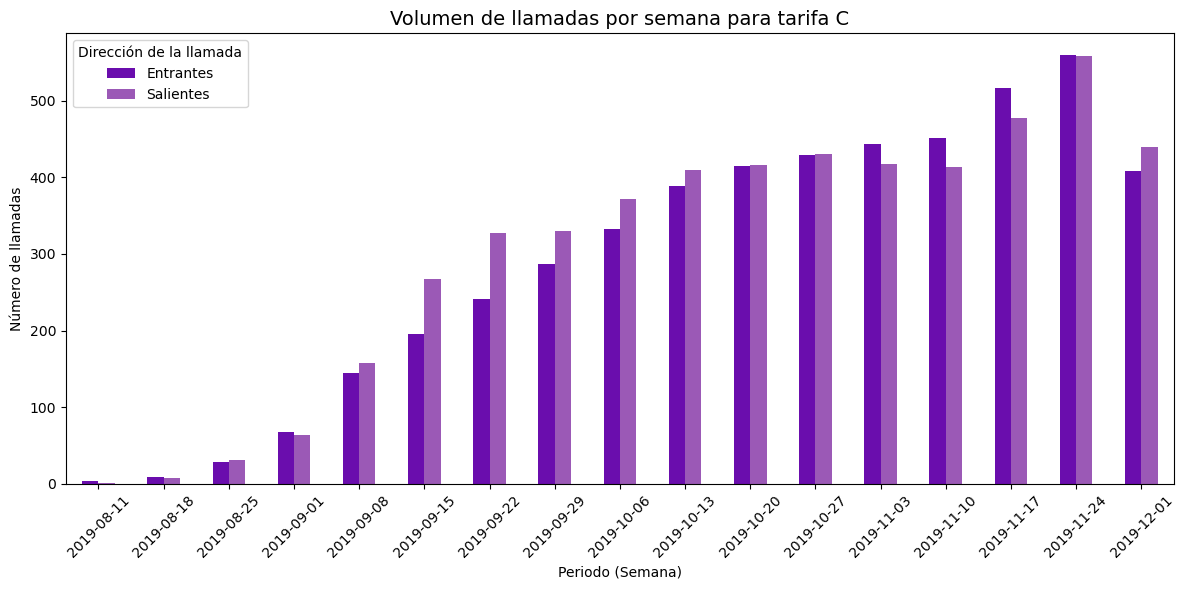

In [42]:
# HAY DIFERENCIAS SIGNIFICATIVAS EN EL VOLUMNE DE LLAMADAS POR TARIFA*DIRECCION?
group_A = dataset_calls[dataset_calls["tariff_plan"]=="A"]
group_B = dataset_calls[dataset_calls["tariff_plan"]=="B"]
group_C = dataset_calls[dataset_calls["tariff_plan"]=="C"]
#GRÁFICO PARA GRUPO A
calls_groupA = (
    group_A
    .groupby([
        pd.Grouper(key="date", freq="W"), 
        "direction"
    ])
    .size()
    .unstack(fill_value=0)
)

calls_groupA = calls_groupA.rename(columns={
    0: "Entrantes",
    1: "Salientes"
})

calls_groupA.index = calls_groupA.index.strftime("%Y-%m-%d")

ax = calls_groupA.plot(
    kind="bar",
    figsize=(12,6),
    color=["#6A0DAD", "#9B59B6"]
)

ax.set_title("Volumen de llamadas por semana para tarifa A", fontsize=14)
ax.set_xlabel("Periodo (Semana)")
ax.set_ylabel("Número de llamadas")
ax.legend(title="Dirección de la llamada")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# GRÁFICO PARA GRUPO B
calls_groupB = (
    group_B
    .groupby([
        pd.Grouper(key="date", freq="W"), 
        "direction"
    ])
    .size()
    .unstack(fill_value=0)
)

calls_groupB = calls_groupB.rename(columns={
    0: "Entrantes",
    1: "Salientes"
})

calls_groupB.index = calls_groupB.index.strftime("%Y-%m-%d")

ax = calls_groupB.plot(
    kind="bar",
    figsize=(12,6),
    color=["#6A0DAD", "#9B59B6"]
)

ax.set_title("Volumen de llamadas por semana para tarifa B", fontsize=14)
ax.set_xlabel("Periodo (Semana)")
ax.set_ylabel("Número de llamadas")
ax.legend(title="Dirección de la llamada")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#GR+AFICO PARA GRUPO C
calls_groupC = (
    group_C
    .groupby([
        pd.Grouper(key="date", freq="W"), 
        "direction"
    ])
    .size()
    .unstack(fill_value=0)
)

calls_groupC = calls_groupC.rename(columns={
    0: "Entrantes",
    1: "Salientes"
})

calls_groupC.index = calls_groupC.index.strftime("%Y-%m-%d")

ax = calls_groupC.plot(
    kind="bar",
    figsize=(12,6),
    color=["#6A0DAD", "#9B59B6"]
)

ax.set_title("Volumen de llamadas por semana para tarifa C", fontsize=14)
ax.set_xlabel("Periodo (Semana)")
ax.set_ylabel("Número de llamadas")
ax.legend(title="Dirección de la llamada")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observamos tendencias contrastantes encuento a la dirección de las llamadas de los grupos y las tarifas con respecto al volumne de llamadas. El grupo A vemos que en un inicio el número de llamadas entrantes era superior a las llamadas salientes, pero esto cambio a aprtir de septiembre. Para el grupo B, vemos que el número de llamadas salientes domina y además en noviembre este número aumento alcanzando o siendo mayor a las 600 llamadas. Y por otra parte, el grupo C, la proporción en cuanto a la dirección de las llamadas es mucho más equilibrada, es decir, la distribución es más equitativa entre las llamadas que entrantes y salientes.

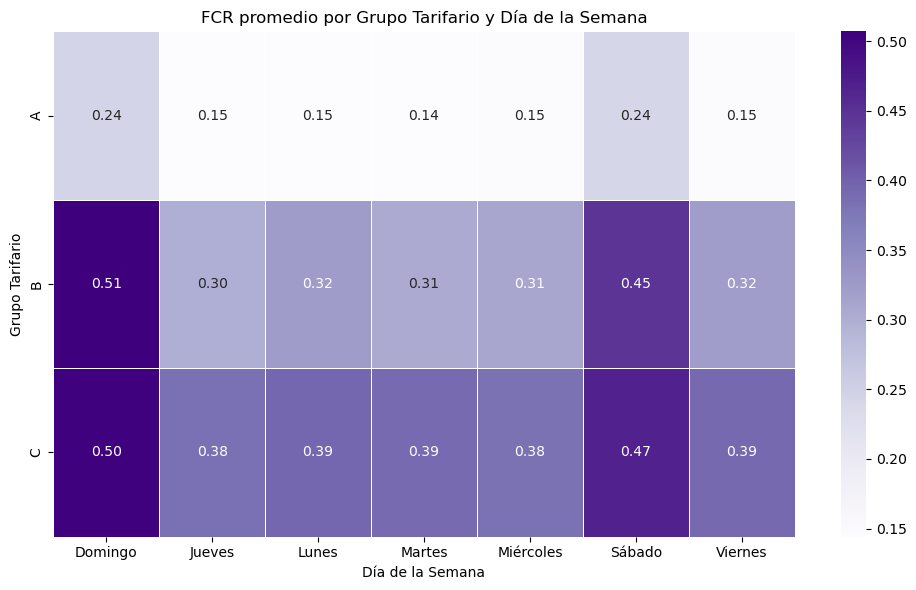

In [ ]:
# Creo un heatmap para visualizar proporciones de llamadas entre grupos tarifarios
# Crear tabla dinámica (promedio FCR = proporción)
heat_data = (
    dataset_calls
    .groupby(["tariff_plan", "weekday_es"])["FCR"]
    .mean()
    .unstack()
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heat_data,
    annot=True,
    fmt=".2f",
    cmap="Purples",  
    linewidths=0.5
)

plt.title("FCR promedio por Grupo Tarifario y Día de la Semana")
plt.ylabel("Grupo Tarifario")
plt.xlabel("Día de la Semana")
plt.tight_layout()
plt.show()

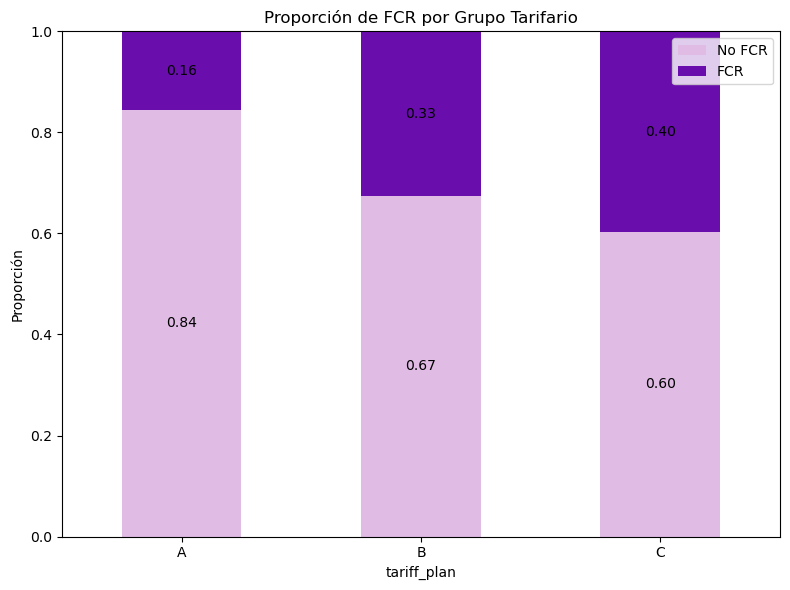

In [23]:
# Barras de proporciones
prop_data = (
    pd.crosstab(dataset_calls["tariff_plan"],
                dataset_calls["FCR"],
                normalize="index")
)

# Renombrar columnas
prop_data.columns = ["No FCR", "FCR"]

ax = prop_data.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=["#E0BBE4", "#6A0DAD"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center")

plt.title("Proporción de FCR por Grupo Tarifario")
plt.ylabel("Proporción")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

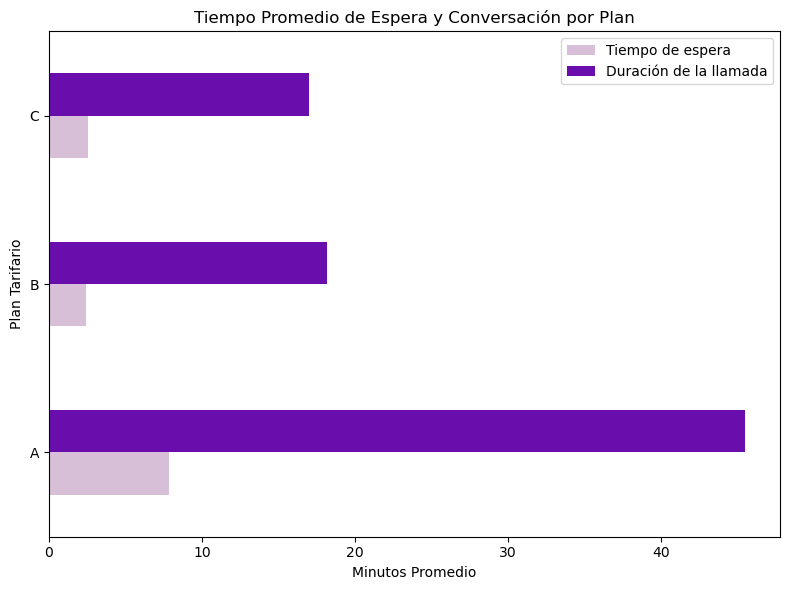

In [29]:

# Calcular promedios por plan
dataset_calls["t_espera_min"] = dataset_calls["t_espera"] / 60
dataset_calls["call_duration_min"] = dataset_calls["call_duration"] / 60
tiempos = (
    dataset_calls
    .groupby("tariff_plan")[["t_espera_min", "call_duration_min"]]
    .mean()
)
tiempos.rename(columns={
    "t_espera_min": "Tiempo de espera",
    "call_duration_min": "Duración de la llamada"
}, inplace=True)
tiempos.plot(
    kind="barh",
    figsize=(8,6),
    color=["#D8BFD8", "#6A0DAD"]
)

plt.title("Tiempo Promedio de Espera y Conversación por Plan")
plt.xlabel("Minutos Promedio")
plt.ylabel("Plan Tarifario")
plt.tight_layout()
plt.show()

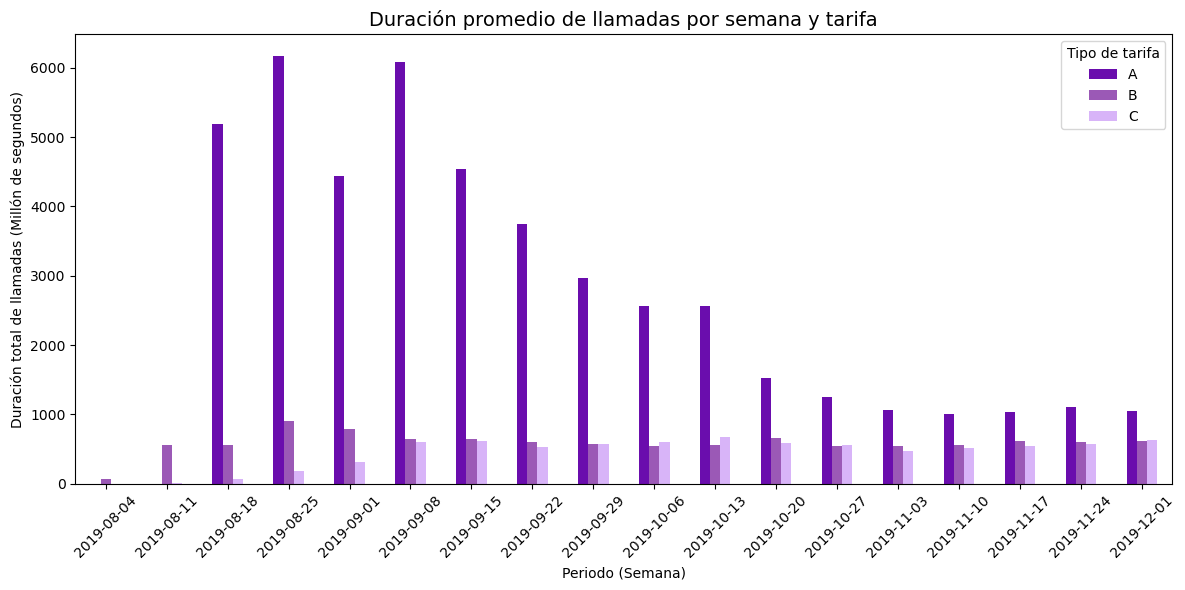

In [16]:
# Serie de tiempo duracion total de las llamadas por grupos, call_duration
calls_group = (
    dataset_merge
    .groupby([
        pd.Grouper(key="date", freq="W"), 
        "tariff_plan"
    ])["call_duration"]
    .mean()
    .unstack(fill_value=0)
)

calls_group.index = calls_group.index.strftime("%Y-%m-%d")

ax = calls_group.plot(
    kind="bar",
    figsize=(12,6),
    color=["#6A0DAD", "#9B59B6", "#D8B4F8"]
)

ax.set_title("Duración promedio de llamadas por semana y tarifa", fontsize=14)
ax.set_xlabel("Periodo (Semana)")
ax.set_ylabel("Duración total de llamadas (Millón de segundos)")
ax.legend(title="Tipo de tarifa")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La duración de las llamadas (tiempo de conversación, NO con espera) es evidente mayor para el grupo A, que es justamente el grupo con menor número de suscriptores. Sin embargo, el tiempo de conversación ha venido reduciendo, y para el 20 de octubre, su valor es mucho mas cercano a los otros dos grupos. El grupo C y B presentan valores muy similares pero ninguno se mantiene mayor constantemente.

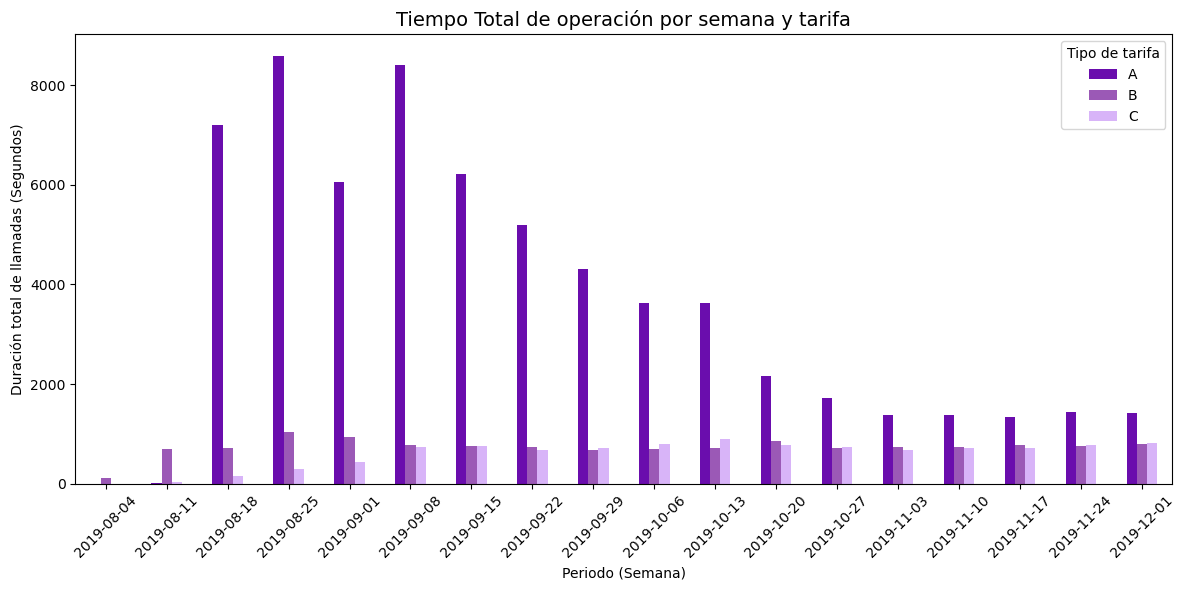

In [44]:
# Serie de tiempo, duración del Tiempo Total de operación por semana de las llamadas por grupos,
calls_group = (
    dataset_merge
    .groupby([
        pd.Grouper(key="date", freq="W"), 
        "tariff_plan"
    ])["total_call_duration"]
    .mean()
    .unstack(fill_value=0)
)

calls_group.index = calls_group.index.strftime("%Y-%m-%d")

ax = calls_group.plot(
    kind="bar",
    figsize=(12,6),
    color=["#6A0DAD", "#9B59B6", "#D8B4F8"]
)

ax.set_title("Tiempo Total de operación por semana y tarifa", fontsize=14)
ax.set_xlabel("Periodo (Semana)")
ax.set_ylabel("Duración total de llamadas (Segundos)")
ax.legend(title="Tipo de tarifa")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

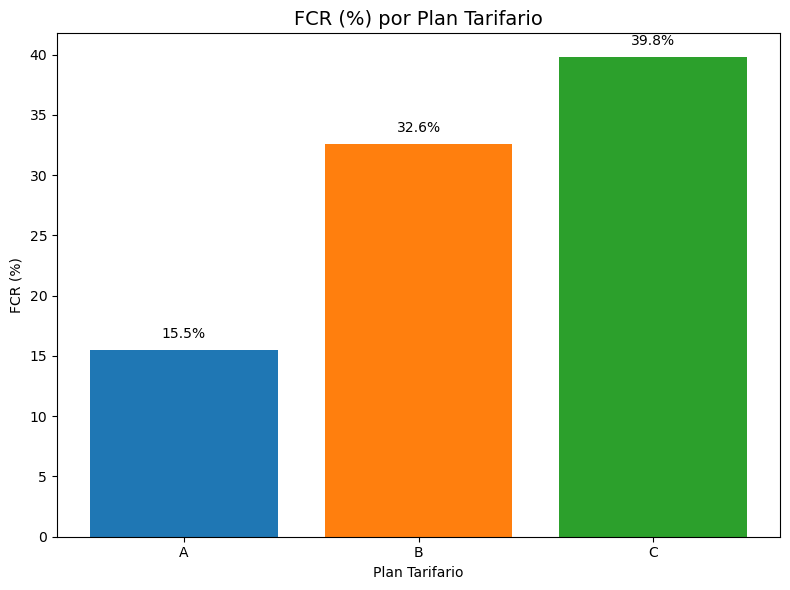

In [19]:
# Calculo FCR por grupo
fcr_by_plan = (
    dataset_calls
    .groupby("tariff_plan")
    .agg(
        FCR_percent = ("FCR", "mean"),
        Avg_Call_Duration = ("call_duration", "mean")
    )
)

# Convertir FCR a porcentaje
fcr_by_plan["FCR_percent"] = fcr_by_plan["FCR_percent"] * 100

# Graficamos
# Crear figura
plt.figure(figsize=(8,6))

plt.bar(
    fcr_by_plan.index,
    fcr_by_plan["FCR_percent"],
    color=["#1f77b4", "#ff7f0e", "#2ca02c"]
)

plt.title("FCR (%) por Plan Tarifario", fontsize=14)
plt.xlabel("Plan Tarifario")
plt.ylabel("FCR (%)")

for i, value in enumerate(fcr_by_plan["FCR_percent"]):
    plt.text(i, value + 1, f"{value:.1f}%", ha='center')

plt.tight_layout()
plt.show()

Mediante las series de tiempo observamos que, el grupo A, el de menor número de suscritores es el que presenta un mayor tiempo de operación promedio (TOM), contrastando con el grupo C, que además de tener mayor núMero de suscritpres su TOM promedio es menor. Adicional a ello, advertimos en el gráfico de barras que Porcentaje de Resolución en el Primer Contacto (FCR) es mayor en el grupo C y B (grupos ás suscriptores que en el grupo A).

*** Hipotesis ***
En los call center, la alta demanda requiere que los operarios estén plenamente informados sobre el producto ofertado con el fin de atender la mayor cantidad de llamadas posible en un periodo de tiempo específico. Es por esto que el indicador TOM (Tiempo Medio de Operación) es uno de los más importantes para evaluar la gestión y productividad. Por otra parte, cuando el cliente ha quedado completamente satisfecho con la primera llamada y todas sus dudas han quedado resueltas, se espera que el cliente no necesite volver a llamar al call center. Por lo tanto, podría decirse que: 
 ***“Cuando el TOM es bajo el Porcentaje de Resolución en el Primer Contacto (FCR) es alto, que presentan una relación inversa o que estas dos variables presentan una relación lineal.”***

In [ ]:
# Comparación de medianas de TOM mediante Kruskal Wallis


group_A = dataset_calls[dataset_calls["tariff_plan"]=="A"]["call_duration"]
group_B = dataset_calls[dataset_calls["tariff_plan"]=="B"]["call_duration"]
group_C = dataset_calls[dataset_calls["tariff_plan"]=="C"]["call_duration"]

stat, p = kruskal(group_A, group_B, group_C)

alpha = 0.05

if p < alpha:
    print("\nConclusión:")
    print("Hay evidencia estadísticamente significativa para afirmar que los tiempos de operación promedio (medianas) difieren entre los grupos tarifarios.")
else:
    print("\nConclusión:")
    print("No hay evidencia suficiente para afirmar que los tiempos de operación promedio (medianas) sean diferentes entre los grupos tarifarios.")




Conclusión:
Hay evidencia estadísticamente significativa para afirmar que los tiempos de operación promedio (medianas) difieren entre los grupos tarifarios.


Resultados del test post hoc de Dunn (ajuste Bonferroni):

              A             B             C
A  1.000000e+00  8.552867e-09  2.646933e-28
B  8.552867e-09  1.000000e+00  2.422845e-07
C  2.646933e-28  2.422845e-07  1.000000e+00

Interpretación de comparaciones por pares:

De acuerdo al test de Bonferroni, el TOM entre los tres grupos es significativamente diferentes entre sí en todos los casos.
Visualización de la distribusión de los tiempo de operación media para cada grupo)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_21776\1267020177.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


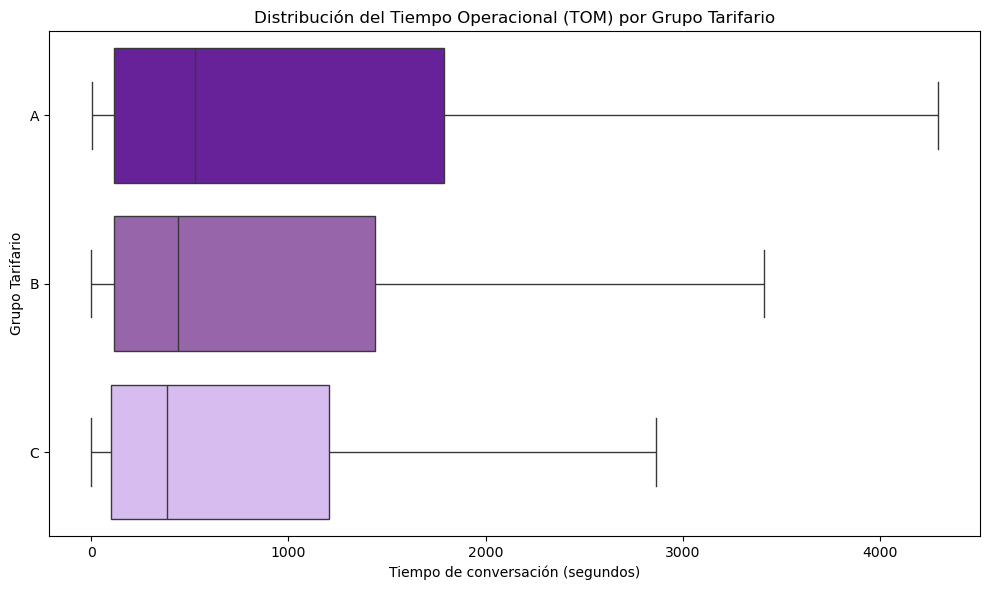

In [ ]:
# Como la prueba Kruskal Wallis fue estadísticamente diferente, utilizaremos un test posthoc para determinar entre cuales grupos hay diferencia

dunn_results = sp.posthoc_dunn(
    dataset_calls,
    val_col="call_duration",
    group_col="tariff_plan",
    p_adjust="bonferroni"
)

print("Resultados del test post hoc de Dunn (ajuste Bonferroni):\n")
print(dunn_results)
print("\nInterpretación de comparaciones por pares:\n")

alpha = 0.05

# Recorrer matriz de resultados
print(f"De acuerdo al test de Bonferroni, el TOM entre los tres grupos es significativamente diferentes entre sí en todos los casos.")

print(f"Visualización de la distribusión de los tiempo de operación media para cada grupo)")

# Gráfico de visualización
plt.figure(figsize=(10,6))

sns.boxplot(
    data=dataset_calls,
    x="call_duration",
    y="tariff_plan",
    order=["A","B","C"],
    palette=["#6A0DAD", "#9B59B6", "#D8B4F8"],
    showfliers=False   
)
plt.title("Distribución del Tiempo Operacional (TOM) por Grupo Tarifario")
plt.xlabel("Tiempo de conversación (segundos)")
plt.ylabel("Grupo Tarifario")

plt.tight_layout()
plt.show()

In [ ]:
# Comparación de medianas de tiempo de espera mediante Kruskal Wallis


group_A = dataset_calls[dataset_calls["tariff_plan"]=="A"]["t_espera"]
group_B = dataset_calls[dataset_calls["tariff_plan"]=="B"]["t_espera"]
group_C = dataset_calls[dataset_calls["tariff_plan"]=="C"]["t_espera"]

stat, p = kruskal(group_A, group_B, group_C)

alpha = 0.05

if p < alpha:
    print("\nConclusión:")
    print("Hay evidencia estadísticamente significativa para afirmar que los tiempos de espera (medianas) difieren entre los grupos tarifarios.")
else:
    print("\nConclusión:")
    print("No hay evidencia suficiente para afirmar que los tiempos de espera (medianas) sean diferentes entre los grupos tarifarios.")


Conclusión:
Hay evidencia estadísticamente significativa para afirmar que los tiempos de espera (medianas) difieren entre los grupos tarifarios.


Resultados del test post hoc de Dunn (ajuste Bonferroni):

              A             B             C
A  1.000000e+00  6.220196e-36  4.398516e-32
B  6.220196e-36  1.000000e+00  1.000000e+00
C  4.398516e-32  1.000000e+00  1.000000e+00

Interpretación de comparaciones por pares:

De acuerdo al test de Bonferroni, el tiempo de espera entre los tres grupos es significativamente diferentes entre los grupos A y B - A y C, mientras que entre B y C no lo son.
Visualización de la distribusión de los tiempo de espera media para cada grupo


C:\Users\Usuario\AppData\Local\Temp\ipykernel_21776\2809637663.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


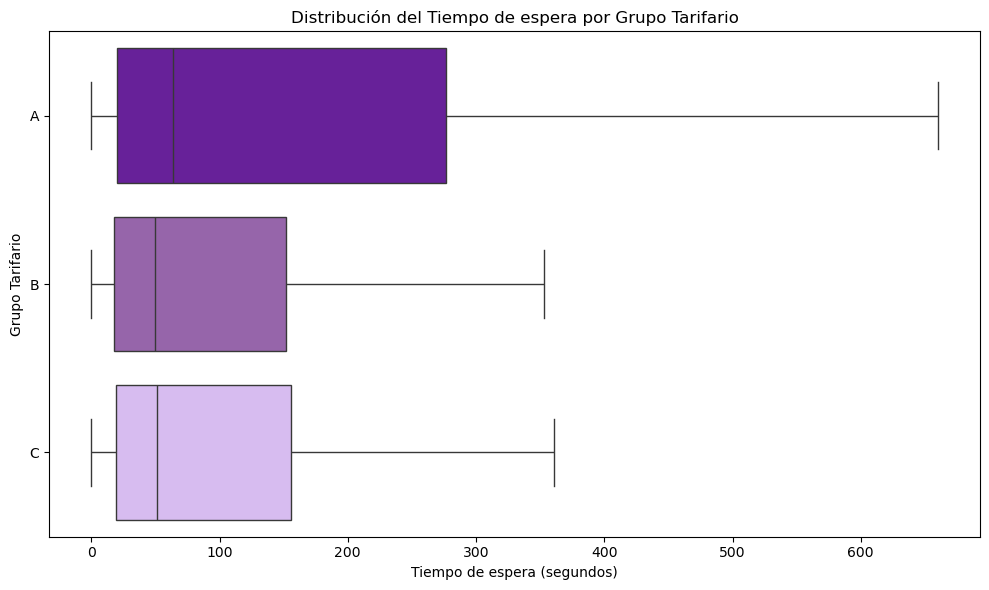

In [48]:
# Como la prueba Kruskal Wallis fue estadísticamente diferente, utilizaremos un test posthoc para determinar entre cuales grupos hay diferencia

dunn_results = sp.posthoc_dunn(
    dataset_calls,
    val_col="t_espera",
    group_col="tariff_plan",
    p_adjust="bonferroni"
)

print("Resultados del test post hoc de Dunn (ajuste Bonferroni):\n")
print(dunn_results)
print("\nInterpretación de comparaciones por pares:\n")

alpha = 0.05

# Recorrer matriz de resultados
print(f"De acuerdo al test de Bonferroni, el tiempo de espera entre los tres grupos es significativamente diferentes entre los grupos A y B - A y C, mientras que entre B y C no lo son.")

print(f"Visualización de la distribusión de los tiempo de espera media para cada grupo")

# Gráfico de visualización
plt.figure(figsize=(10,6))

sns.boxplot(
    data=dataset_calls,
    x="t_espera",
    y="tariff_plan",
    order=["A","B","C"],
    palette=["#6A0DAD", "#9B59B6", "#D8B4F8"],
    showfliers=False   
)
plt.title("Distribución del Tiempo de espera por Grupo Tarifario")
plt.xlabel("Tiempo de espera (segundos)")
plt.ylabel("Grupo Tarifario")

plt.tight_layout()
plt.show()

La gráfica y el estadístico nos confirman que los grupos con mayor número de usuarios (B y C) tienen significativamente un tiempo de espera menor que el grupo A. Esto nos perite afirmar que la atención al cliente de las trifas B y C es mejor.

Resultados prueba Chi-cuadrado
Chi2 = 1277.5763
p-value = 0.0000
Grados de libertad = 2

Existe evidencia estadísticamente significativa para afirmar que el FCR depende del grupo tarifario.
Es decir, hay asociación entre el plan tarifario y la resolución en primera llamada.


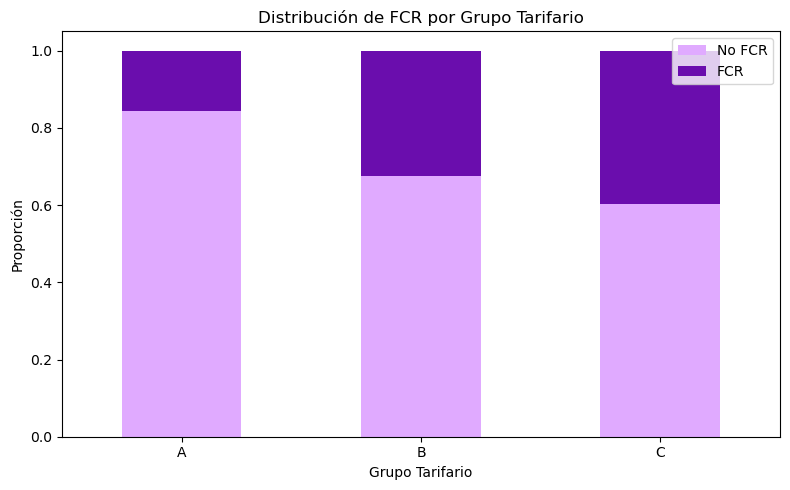

In [ ]:
# Comparo el PCR entre grupos

tabla = pd.crosstab(dataset_calls["tariff_plan"],
                    dataset_calls["FCR"])

chi2, p, dof, expected = stats.chi2_contingency(tabla)

print("Resultados prueba Chi-cuadrado")
print(f"Chi2 = {chi2:.4f}")
print(f"p-value = {p:.4f}")
print(f"Grados de libertad = {dof}\n")

# Interpretación 
if p < alpha:
    print("Existe evidencia estadísticamente significativa para afirmar que el FCR depende del grupo tarifario.")
    print("Es decir, hay asociación entre el plan tarifario y la resolución en primera llamada.")
else:
    print("No existe evidencia suficiente para afirmar que el FCR depende del grupo tarifario.")
    print("No se detecta asociación estadísticamente significativa entre ambas variables.")
# Gráfico
tabla_prop = (
    pd.crosstab(dataset_calls["tariff_plan"],
                dataset_calls["FCR"],
                normalize="index")
)

tabla_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["#e0aaff", "#6a0dad"]
)

plt.title("Distribución de FCR por Grupo Tarifario")
plt.ylabel("Proporción")
plt.xlabel("Grupo Tarifario")
plt.xticks(rotation=0)
plt.legend(["No FCR", "FCR"])
plt.tight_layout()
plt.show()


Coeficiente de correlación entre la duración de las llamadas para el grupo A: -0.0872


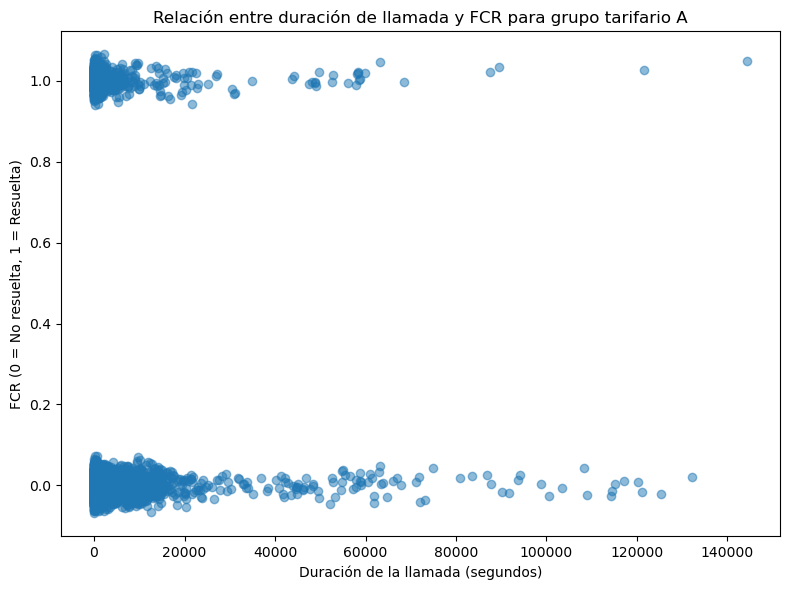

Coeficiente de correlación entre la duración de las llamadas para el grupo A: -0.1126


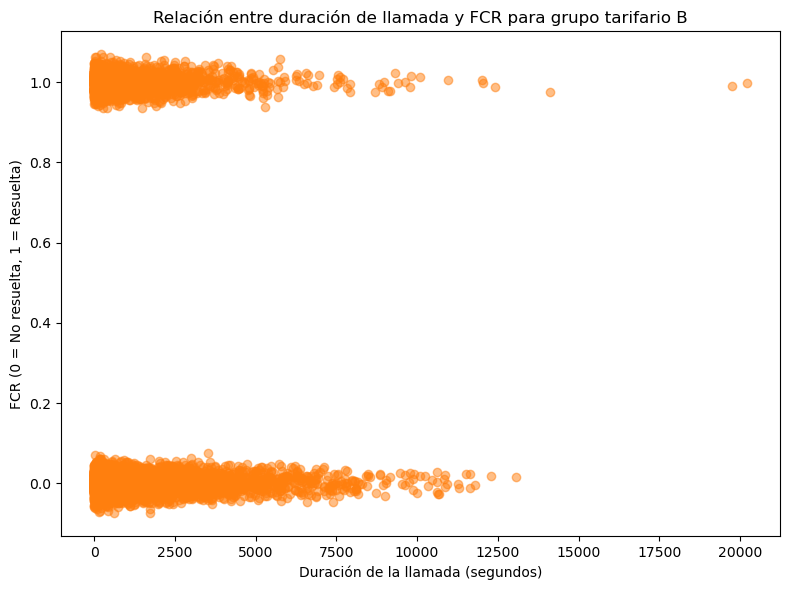

Coeficiente de correlación entre la duración de las llamadas para el grupo C: -0.1443


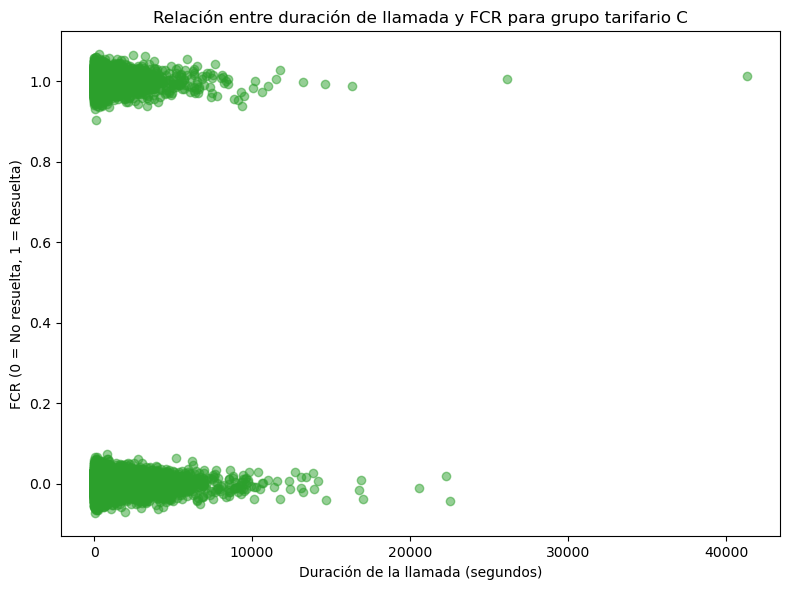

In [57]:
# Correlacion entre la duración de la llamada y FCR POR GRUPO
# GRUPO A
group_A = dataset_calls[dataset_calls["tariff_plan"]=="A"]
correlation_spearman = group_A["call_duration"].corr(
    group_A["FCR"],
    method="spearman"
)

print(f"Coeficiente de correlación entre la duración de las llamadas para el grupo A: {correlation_spearman:.4f}")

# Gráfico de dispersion
colores = {
    "A": "#1f77b4",
    "B": "#ff7f0e",
    "C": "#2ca02c"
}


plt.figure(figsize=(8,6))

for i, plan in enumerate(orden):
    subset = group_A[group_A["tariff_plan"] == plan].copy()
    subset["FCR_jitter"] = subset["FCR"] + np.random.normal(0, 0.02, len(subset))
    
    plt.scatter(
        subset["call_duration"],
        subset["FCR_jitter"],
        label=f"Plan {plan}",
        alpha=0.5,
        color=colores[plan],
        zorder=i  # mayor zorder = más al frente
    )

plt.xlabel("Duración de la llamada (segundos)")
plt.ylabel("FCR (0 = No resuelta, 1 = Resuelta)")
plt.title("Relación entre duración de llamada y FCR para grupo tarifario A")
plt.tight_layout()
plt.show()

# GRUPO B
group_B = dataset_calls[dataset_calls["tariff_plan"]=="B"]
correlation_spearman = group_B["call_duration"].corr(
    group_B["FCR"],
    method="spearman"
)

print(f"Coeficiente de correlación entre la duración de las llamadas para el grupo A: {correlation_spearman:.4f}")

# Gráfico de dispersion
colores = {
    "A": "#1f77b4",
    "B": "#ff7f0e",
    "C": "#2ca02c"
}


plt.figure(figsize=(8,6))


for i, plan in enumerate(orden):
    subset = group_B[group_B["tariff_plan"] == plan].copy()
    subset["FCR_jitter"] = subset["FCR"] + np.random.normal(0, 0.02, len(subset))
    
    plt.scatter(
        subset["call_duration"],
        subset["FCR_jitter"],
        label=f"Plan {plan}",
        alpha=0.5,
        color=colores[plan],
        zorder=i  #
    )

plt.xlabel("Duración de la llamada (segundos)")
plt.ylabel("FCR (0 = No resuelta, 1 = Resuelta)")
plt.title("Relación entre duración de llamada y FCR para grupo tarifario B")
plt.tight_layout()
plt.show()

# GRUPO C
group_C = dataset_calls[dataset_calls["tariff_plan"]=="C"]
correlation_spearman = group_C["call_duration"].corr(
    group_C["FCR"],
    method="spearman"
)

print(f"Coeficiente de correlación entre la duración de las llamadas para el grupo C: {correlation_spearman:.4f}")

# Gráfico de dispersion
colores = {
    "A": "#1f77b4",
    "B": "#ff7f0e",
    "C": "#2ca02c"
}


plt.figure(figsize=(8,6))


for i, plan in enumerate(orden):
    subset = group_C[group_C["tariff_plan"] == plan].copy()
    subset["FCR_jitter"] = subset["FCR"] + np.random.normal(0, 0.02, len(subset))
    
    plt.scatter(
        subset["call_duration"],
        subset["FCR_jitter"],
        label=f"Plan {plan}",
        alpha=0.5,
        color=colores[plan],
        zorder=i  #
    )

plt.xlabel("Duración de la llamada (segundos)")
plt.ylabel("FCR (0 = No resuelta, 1 = Resuelta)")
plt.title("Relación entre duración de llamada y FCR para grupo tarifario C")
plt.tight_layout()
plt.show()

Para los tres grupos, el coeficiente de correlación Spearman entre el FCR y el tiempo de conversación es bajo. Sin embargo es negativo, esto indica que entre mayor tiempo ocupe la conversación, mayor probabilidad de que el cliente vuelva a llamar en menos de 24 hrs. 

***Regresión Logística***

In [ ]:
# Realizaré una regresión logística incluyendo la interacción entre las variables call_duration y tariff_plan

dataset_calls["FCR"] = dataset_calls["FCR"].astype(int)
model = smf.logit(
    "FCR ~ call_duration * C(tariff_plan)",
    data=dataset_calls
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.583630
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    FCR   No. Observations:                27549
Model:                          Logit   Df Residuals:                    27543
Method:                           MLE   Df Model:                            5
Date:                Sun, 01 Mar 2026   Pseudo R-squ.:                 0.04793
Time:                        22:56:53   Log-Likelihood:                -16078.
converged:                       True   LL-Null:                       -16888.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -1.6960      0.032    -52

c:\Users\Usuario\anaconda3\envs\proyecto_python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


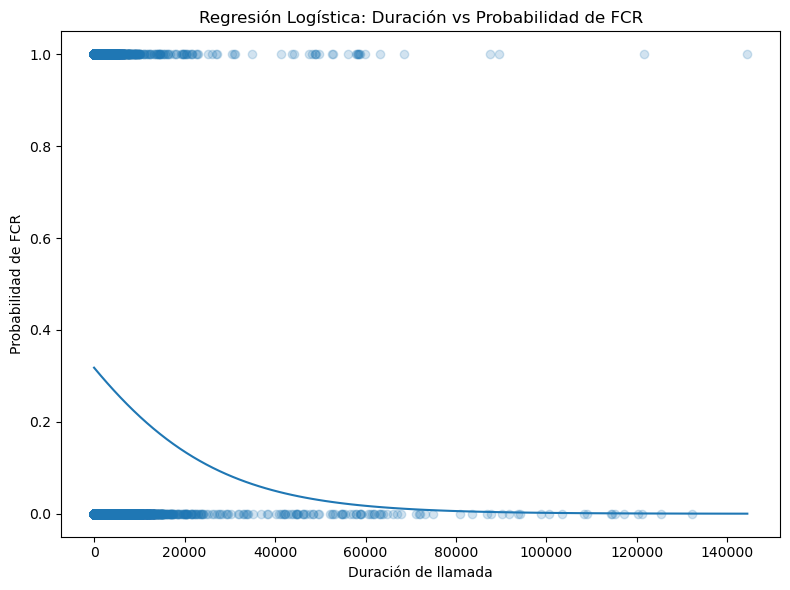

In [39]:
# CUrva logística
x_values = np.linspace(
    dataset_calls["call_duration"].min(),
    dataset_calls["call_duration"].max(),
    100
).reshape(-1,1)

# Probabilidades predichas
y_prob = model.predict_proba(x_values)[:,1]

plt.figure(figsize=(8,6))

plt.scatter(
    dataset_calls["call_duration"],
    dataset_calls["FCR"],
    alpha=0.2
)

plt.plot(x_values, y_prob)

plt.title("Regresión Logística: Duración vs Probabilidad de FCR")
plt.xlabel("Duración de llamada")
plt.ylabel("Probabilidad de FCR")

plt.tight_layout()
plt.show()

In [ ]:
# Realizaré una regresión logística incluyendo la interacción entre las variables call_duration y tariff_plan, e incluiré otras variables explicativas

dataset_calls["FCR"] = dataset_calls["FCR"].astype(int)
model = smf.logit(
    "FCR ~ call_duration * C(tariff_plan) + C(direction) + weekday_es",
    data=dataset_calls
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.576497
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    FCR   No. Observations:                27549
Model:                          Logit   Df Residuals:                    27536
Method:                           MLE   Df Model:                           12
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                 0.05957
Time:                        14:34:29   Log-Likelihood:                -15882.
converged:                       True   LL-Null:                       -16888.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -0.9570      0.070    -13

El análisis multivariado sugiere que la probabilidad de resolución en primera llamada (FCR) depende principalmente del tipo de plan tarifario, la dirección de la llamada y el día de la semana. Las llamadas realizadas en días laborales presentan menor probabilidad de resolución comparadas con el día de referencia, lo que podría reflejar mayor saturación operativa en dichos períodos.

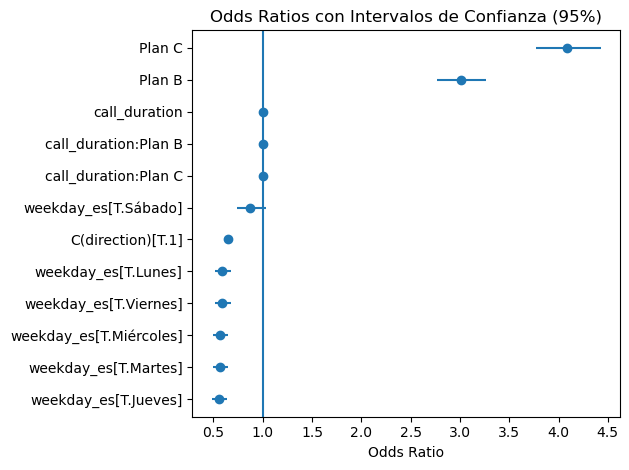

In [ ]:
# Extraer coeficientes
params = model.params
conf = model.conf_int()
# Convertir a Odds Ratios
odds_ratios = np.exp(params)
conf_lower = np.exp(conf[0])
conf_upper = np.exp(conf[1])

# Crear dataframe
or_df = pd.DataFrame({
    "OR": odds_ratios,
    "CI_lower": conf_lower,
    "CI_upper": conf_upper
})

# Eliminar intercepto (no suele mostrarse)
or_df = or_df.drop("Intercept")

# Ordenar para mejor visualización
or_df = or_df.sort_values("OR")
or_df.index = or_df.index.str.replace("C(tariff_plan)[T.B]", "Plan B")
or_df.index = or_df.index.str.replace("C(tariff_plan)[T.C]", "Plan C")

# ---- GRAFICO ----
plt.figure()

plt.errorbar(
    or_df["OR"],
    or_df.index,
    xerr=[or_df["OR"] - or_df["CI_lower"],
          or_df["CI_upper"] - or_df["OR"]],
    fmt='o'
)

plt.axvline(x=1)  

plt.xlabel("Odds Ratio")
plt.title("Odds Ratios con Intervalos de Confianza (95%)")
plt.tight_layout()
plt.show()

### Conclusiones modelo:

1. La duración de la llamada no tiene un efecto sobre el FCR
2. Los usuarios en Tarifa B tienen aproximadamente 3 veces más probabilidad de FCR que Tarifa A.
3. Los usuarios en Tarifa C tienen aproximadamente 4 veces más probabilidad de FCR que Tarifa A.
4. La duración de la llamada en interacción con la tarifa tampoco explica la variación del FCR.
5. Las llamadas que ocurren entre semana, tienen menor posibilidad de no necesitar una segunda llamada (FCR).


#### RECOMENDACIONES:

1. Dado que la tarifa C es la que presenta mayor FCR y además es la tarifa preferida entre los usuarios, es necesario seguir investigando cuál es el factor diferenciador. ¿Hay mayor capacitación sobre estos productos? ¿Los procesos son más simples? ¿Qué tipo de productos maneja?. Con estas respuestas se podría aplicar/copiar estas características a la tarifa A.

2. El Tiempo Operativo (TOM) no explica el FCR, sin embargo, podría ser provechoso identificar el rango de tiempo más provechoso. Lo suficientemente largo para adelantar los procesos pero no cansar a los clientes y no comprometer la productividad de cada operario.

3. Encontramos demasiadas llamadas salientes que son perdidas (>50%). Estos son recursos desperdiciados. Se deben priorizar los horarios favorables para los clientes o implementar otros medios de comunicación como el Whatsapp o la mensajería de texto.

4. De acuerdo a nuestro modelo, el FCR disminuía los días de semana. Es  necesario investigar cuáles son los días de mayor carga y si de pronto hay temas recurrentes durante estos días con mayor complejidad operativa, que pueda estar retrasando la demanda.


In [26]:
fig = px.histogram(
    dataset_merge,
    x="call_duration",
    color="tariff_plan",
    nbins=50,
    barmode="overlay",   # superpuestos
    opacity=0.6,
    title="Distribución de la duración de llamadas por plan tarifario"
)

fig.update_layout(
    xaxis_title="Duración de llamada (segundos)",
    yaxis_title="Frecuencia"
)

fig.show()

In [29]:
fig = px.histogram(
    dataset_merge,
    x="calls_count",
    color="tariff_plan",
    nbins=50,
    barmode="overlay",   # superpuestos
    opacity=0.6,
    title="Distribución de la duración de llamadas por plan tarifario"
)

fig.update_layout(
    xaxis_title="Duración de llamada (segundos)",
    yaxis_title="Frecuencia"
)

fig.show()